In [1]:
import scanpy as sc
from sklearn.metrics import adjusted_rand_score
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc
from _utils.scanpy import scanpy_pp
from _utils.sankey import plot_anndata_sankey


In [ ]:
# Configurations
data_path = ..

In [3]:
adata = sc.read_h5ad(data_path)


In [4]:
adata.X = adata.layers["raw_ro"].copy()
adata.layers["counts"] = adata.layers["raw_ro"].copy()


In [5]:
scanpy_pp(adata, use_hvg=True)

---begin normalization---
---begin log---
---begin hvg---
---begin pca---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [6]:
sc.tl.umap(adata)

In [7]:
sc.tl.leiden(
    adata,
    resolution=0.01,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    key_added="leiden_4"
)
sc.tl.leiden(
    adata,
    resolution=0.35,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    key_added="leiden"
)

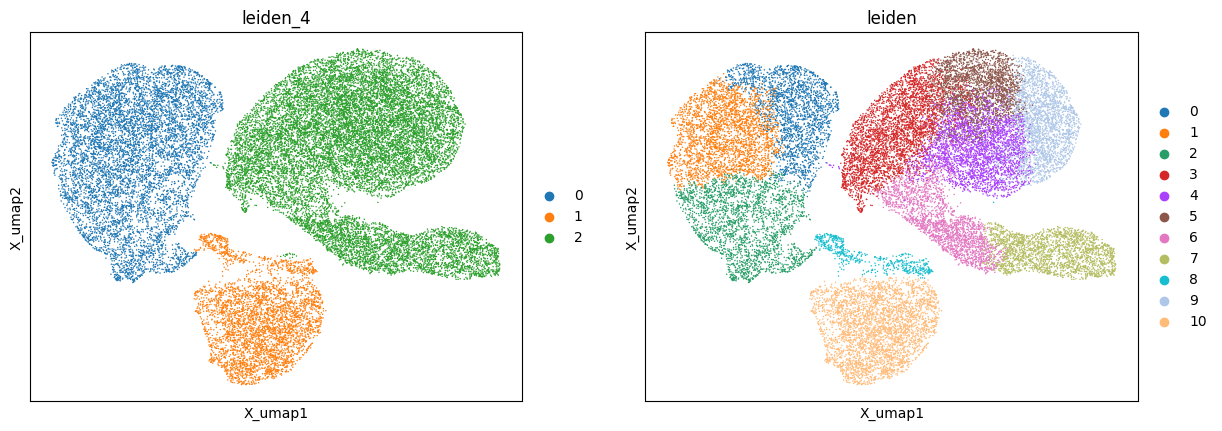

In [8]:
sc.pl.embedding(adata, color = ['leiden_4', 'leiden'], basis = "X_umap")

In [9]:
adata_0 = adata[adata.obs["leiden_4"].isin(['0'])].copy()
adata_1 = adata[adata.obs["leiden_4"].isin(['1'])].copy()
adata_2 = adata[adata.obs["leiden_4"].isin(['2'])].copy()
adata.obs['scanpy_hierarchy'] = ''

In [10]:
adata_0.X = adata_0.layers["counts"]


In [11]:
scanpy_pp(adata_0, n_hvg=200, use_hvg=True, n_neighbors=15, n_pcs=50)


---begin normalization---
---begin log---
---begin hvg---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


---begin pca---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [12]:
sc.tl.leiden(
    adata_0,
    resolution=0.2,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    key_added="leiden_0"
)

In [13]:
adata_0.obs["leiden_0"].value_counts()

leiden_0
0    6540
1     422
2     408
Name: count, dtype: int64

In [14]:
cluster_mapping = {
    '0': '0_0',
    '1': '0_1', 
    '2': '0_2'
}
adata.obs['scanpy_hierarchy'] = adata.obs['scanpy_hierarchy'].astype(str)
hierarchy_map = {}
for cell_name in adata_0.obs_names:
    cluster_val = str(adata_0.obs.loc[cell_name, "leiden_0"])
    if cluster_val in cluster_mapping:
        hierarchy_map[cell_name] = cluster_mapping[cluster_val]

for cell_name in adata.obs_names:
    if cell_name in hierarchy_map:
        adata.obs.at[cell_name, "scanpy_hierarchy"] = hierarchy_map[cell_name]

print(adata.obs['scanpy_hierarchy'].value_counts().sort_index())

scanpy_hierarchy
       19927
0_0     6540
0_1      422
0_2      408
Name: count, dtype: int64


In [15]:
adata_1.X = adata_1.layers["counts"]


In [16]:
scanpy_pp(adata_1,n_hvg=200, use_hvg=True, n_neighbors=15, n_pcs=50)


---begin normalization---
---begin log---
---begin hvg---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


---begin pca---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [17]:
sc.tl.leiden(
    adata_1,
    resolution=0.01,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    key_added="leiden_1"
)

In [18]:
adata_1.obs["leiden_1"].value_counts()

leiden_1
1    3721
0     308
Name: count, dtype: int64

In [19]:
cluster_mapping = {
    '0': '1_0',
    '1': '1_1', 
}
adata.obs['scanpy_hierarchy'] = adata.obs['scanpy_hierarchy'].astype(str)
hierarchy_map = {}
for cell_name in adata_1.obs_names:
    cluster_val = str(adata_1.obs.loc[cell_name, "leiden_1"])
    if cluster_val in cluster_mapping:
        hierarchy_map[cell_name] = cluster_mapping[cluster_val]

for cell_name in adata.obs_names:
    if cell_name in hierarchy_map:
        adata.obs.at[cell_name, "scanpy_hierarchy"] = hierarchy_map[cell_name]

print(adata.obs['scanpy_hierarchy'].value_counts().sort_index())

scanpy_hierarchy
       15898
0_0     6540
0_1      422
0_2      408
1_0      308
1_1     3721
Name: count, dtype: int64


In [20]:
adata_2.X = adata_2.layers["counts"].copy()


In [21]:
scanpy_pp(adata_2, n_hvg=100, use_hvg=True, n_neighbors=15, n_pcs=50)


---begin normalization---
---begin log---
---begin hvg---
---begin pca---


/home/zhenwei/miniconda3/envs/scHetero/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [22]:
sc.tl.leiden(
    adata_2,
    resolution=0.5,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    key_added="leiden_2"
)

In [23]:
adata_2.obs["leiden_2"].value_counts()

leiden_2
2    5485
1    3238
0    2687
3    1818
4    1356
5    1314
Name: count, dtype: int64

In [24]:
cluster_mapping = {
    '0': '2_0',
    '1': '2_1',
    '2': '2_2',
    '3': '2_3',
    '4': '2_4',
    '5': '2_5',
}
adata.obs['scanpy_hierarchy'] = adata.obs['scanpy_hierarchy'].astype(str)
hierarchy_map = {}
for cell_name in adata_2.obs_names:
    cluster_val = str(adata_2.obs.loc[cell_name, "leiden_2"])
    if cluster_val in cluster_mapping:
        hierarchy_map[cell_name] = cluster_mapping[cluster_val]

for cell_name in adata.obs_names:
    if cell_name in hierarchy_map:
        adata.obs.at[cell_name, "scanpy_hierarchy"] = hierarchy_map[cell_name]

print(adata.obs['scanpy_hierarchy'].value_counts().sort_index())

scanpy_hierarchy
0_0    6540
0_1     422
0_2     408
1_0     308
1_1    3721
2_0    2687
2_1    3238
2_2    5485
2_3    1818
2_4    1356
2_5    1314
Name: count, dtype: int64


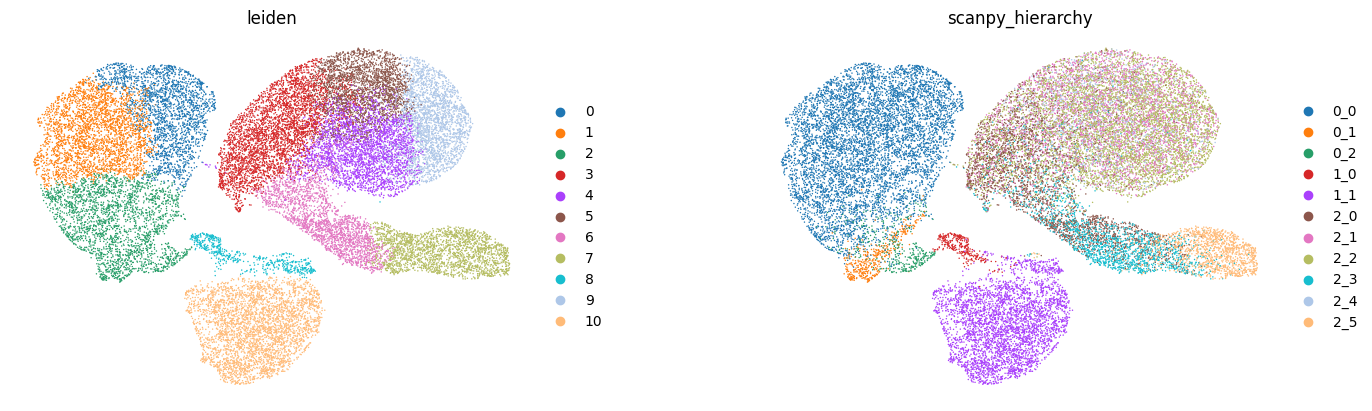

In [25]:
sc.pl.umap(adata, color=['leiden', 'scanpy_hierarchy'], frameon=False, wspace=0.3)

In [26]:
ari_0 = adjusted_rand_score(adata_0.obs['leiden'], adata_0.obs['leiden_0'])
ari_1 = adjusted_rand_score(adata_1.obs['leiden'], adata_1.obs['leiden_1'])
ari_2 = adjusted_rand_score(adata_2.obs['leiden'], adata_2.obs['leiden_2'])
ari_all = adjusted_rand_score(adata.obs['leiden'], adata.obs['scanpy_hierarchy'])

In [27]:
print(ari_0, ari_1, ari_2, ari_all)

0.04886158413359695 0.6238912512381122 0.15947220344661306 0.39227852854355916


In [28]:
plot_anndata_sankey(adata, sort_label='leiden_4', left_label='scanpy_hierarchy', right_label='leiden')